# Welcome to Colab!

# Campus Placement Prediction using Machine Learning

# Project Overview

This project aims to predict whether a student will be placed during campus recruitment using Machine Learning. Before building a predictive model, it is essential to understand the dataset, perform exploratory data analysis (EDA), identify data quality issues, and preprocess the data.

This notebook focuses on understanding the dataset through visualizations and statistical analysis.

# Problem Statement

Campus placements are influenced by several academic and technical factors such as CGPA, coding skills, internship experience, projects, certifications, communication skills, and aptitude.

The objective of this project is to analyze these factors and prepare the dataset for building a machine learning model that can predict whether a student will be placed.

# Objectives

The objectives of this notebook are:

- Understand the structure of the dataset.
- Explore all features using descriptive statistics.
- Identify missing values and duplicate records.
- Analyze the distribution of numerical and categorical features.
- Study the relationship between different variables and placement status.
- Detect potential outliers.
- Generate meaningful insights from the data.
- Prepare the dataset for preprocessing and machine learning.

In [21]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [22]:
# Load Dataset
df = pd.read_csv("/content/placedata_v2_0_synthetic.csv")

# Dataset Overview

This section provides an overview of the dataset, including its structure, dimensions, feature names, data types, and summary statistics. Understanding these characteristics helps identify the nature of the data before performing exploratory data analysis (EDA) and preprocessing.

In [23]:
# Display the first 5 rows of the dataset
df.head()

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,1,7.5,1,1,1,65,4.4,No,No,61,79,NotPlaced
1,2,8.9,0,3,2,90,4.0,Yes,Yes,78,82,Placed
2,3,7.3,1,2,2,82,4.8,Yes,No,79,80,NotPlaced
3,4,7.5,1,1,2,85,4.4,Yes,Yes,81,80,Placed
4,5,8.3,1,2,2,86,4.5,Yes,Yes,74,88,Placed


In [24]:
# Display the last 5 rows of the dataset
df.tail()

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
9995,9996,7.5,1,1,2,72,3.9,Yes,No,85,66,NotPlaced
9996,9997,7.4,0,1,0,90,4.8,No,No,84,67,Placed
9997,9998,8.4,1,3,0,70,4.8,Yes,Yes,79,81,Placed
9998,9999,8.9,0,3,2,87,4.8,Yes,Yes,71,85,Placed
9999,10000,8.4,0,1,1,66,3.8,No,No,62,66,NotPlaced


In [25]:
# Number of rows and columns
print("Dataset Shape:", df.shape)
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Dataset Shape: (10000, 12)
Number of Rows: 10000
Number of Columns: 12


In [26]:
# Display all column names
df.columns

Index(['StudentID', 'CGPA', 'Internships', 'Projects',
       'Workshops/Certifications', 'AptitudeTestScore', 'SoftSkillsRating',
       'ExtracurricularActivities', 'PlacementTraining', 'SSC_Marks',
       'HSC_Marks', 'PlacementStatus'],
      dtype='object')

In [27]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  10000 non-null  int64  
 1   CGPA                       10000 non-null  float64
 2   Internships                10000 non-null  int64  
 3   Projects                   10000 non-null  int64  
 4   Workshops/Certifications   10000 non-null  int64  
 5   AptitudeTestScore          10000 non-null  int64  
 6   SoftSkillsRating           10000 non-null  float64
 7   ExtracurricularActivities  10000 non-null  object 
 8   PlacementTraining          10000 non-null  object 
 9   SSC_Marks                  10000 non-null  int64  
 10  HSC_Marks                  10000 non-null  int64  
 11  PlacementStatus            10000 non-null  object 
dtypes: float64(2), int64(7), object(3)
memory usage: 937.6+ KB


In [28]:
# Summary statistics of numerical features
df.describe().T

,count,mean,std,min,25%,50%,75%,max
StudentID,10000.0,5000.50000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
CGPA,10000.0,7.69801,0.640131,6.5,7.40,7.7,8.20,9.1
Internships,10000.0,1.04920,0.665901,0.0,1.00,1.0,1.00,2.0
Projects,10000.0,2.02660,0.867968,0.0,1.00,2.0,3.00,3.0
Workshops/Certifications,10000.0,1.01320,0.904272,0.0,0.00,1.0,2.00,3.0
AptitudeTestScore,10000.0,79.44990,8.159997,60.0,73.00,80.0,87.00,90.0
SoftSkillsRating,10000.0,4.32396,0.411622,3.0,4.00,4.4,4.70,4.8
SSC_Marks,10000.0,69.15940,10.430459,55.0,59.00,70.0,78.00,90.0
HSC_Marks,10000.0,74.50150,8.919527,57.0,67.00,73.0,83.00,88.0


In [29]:
# Display data types of all columns
df.dtypes

,0
StudentID,int64
CGPA,float64
Internships,int64
Projects,int64
Workshops/Certifications,int64
AptitudeTestScore,int64
SoftSkillsRating,float64
ExtracurricularActivities,object
PlacementTraining,object
SSC_Marks,int64


# Data Quality Assessment

Before building a machine learning model, it is important to assess the quality of the dataset. In this section, we will examine missing values, duplicate records, unique values, and the overall quality of the data to identify any preprocessing requirements.

In [30]:
# Check missing values
missing_values = df.isnull().sum()
missing_values

,0
StudentID,0
CGPA,0
Internships,0
Projects,0
Workshops/Certifications,0
AptitudeTestScore,0
SoftSkillsRating,0
ExtracurricularActivities,0
PlacementTraining,0
SSC_Marks,0


In [31]:
# Missing value percentage
missing_percentage = (df.isnull().sum()/len(df))*100
missing_percentage.sort_values(ascending=False)

,0
StudentID,0.0
CGPA,0.0
Internships,0.0
Projects,0.0
Workshops/Certifications,0.0
AptitudeTestScore,0.0
SoftSkillsRating,0.0
ExtracurricularActivities,0.0
PlacementTraining,0.0
SSC_Marks,0.0


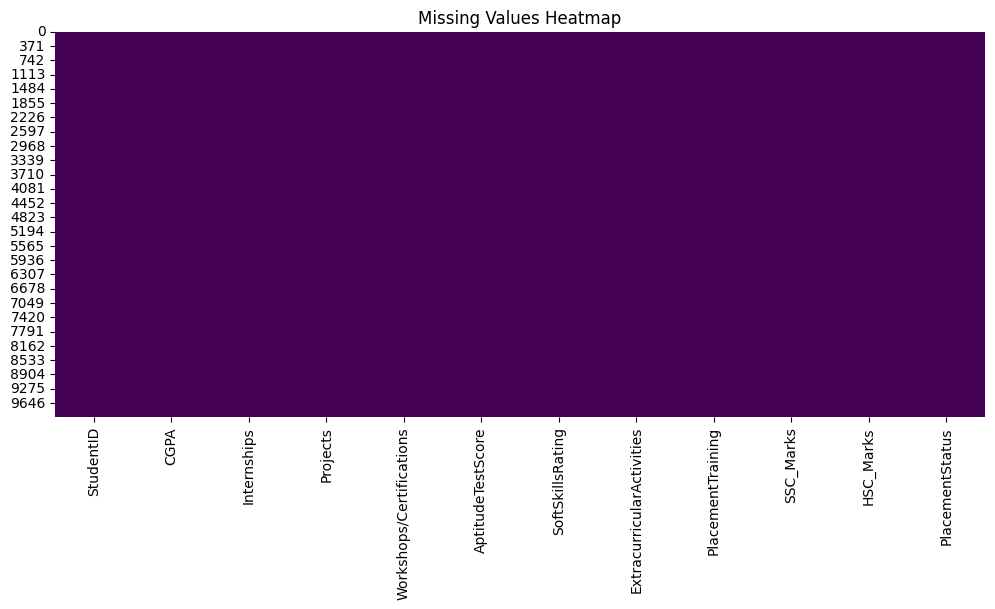

In [32]:
plt.figure(figsize=(12,5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

In [33]:
# Check duplicate rows
duplicates = df.duplicated().sum()
print("Duplicate Rows :", duplicates)

Duplicate Rows : 0


In [34]:
# Remove duplicate rows
df = df.drop_duplicates()
print("Dataset Shape After Removing Duplicates:", df.shape)

Dataset Shape After Removing Duplicates: (10000, 12)


In [35]:
# Unique values in each column
df.nunique().sort_values()

,0
ExtracurricularActivities,2
PlacementTraining,2
PlacementStatus,2
Internships,3
Workshops/Certifications,4
Projects,4
SoftSkillsRating,19
CGPA,27
AptitudeTestScore,31
HSC_Marks,32


In [36]:
# Count numerical and categorical columns
print("Numerical Columns :", len(df.select_dtypes(include=['int64','float64']).columns))
print("Categorical Columns :", len(df.select_dtypes(include=['object']).columns))

Numerical Columns : 9
Categorical Columns : 3


In [37]:
feature_description = pd.DataFrame({
    "Feature": df.columns,
    "Data Type": df.dtypes.values,
    "Missing Values": df.isnull().sum().values,
    "Unique Values": df.nunique().values
})
feature_description

,Feature,Data Type,Missing Values,Unique Values
0,StudentID,int64,0,10000
1,CGPA,float64,0,27
2,Internships,int64,0,3
3,Projects,int64,0,4
4,Workshops/Certifications,int64,0,4
5,AptitudeTestScore,int64,0,31
6,SoftSkillsRating,float64,0,19
7,ExtracurricularActivities,object,0,2
8,PlacementTraining,object,0,2
9,SSC_Marks,int64,0,36


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is the process of analyzing and visualizing the dataset to discover patterns, trends, relationships, and anomalies. It helps in understanding the data before applying machine learning algorithms.

The following analysis focuses on the distribution of features, relationships with the target variable, and important insights that may influence placement prediction.

 Target Variable Analysis: Balanced Metric Verification
This plot breaks down the density footprint of our primary classification target parameter, **PlacementStatus** (Placed vs. NotPlaced), across our engineering talent pool.

 Key Strategic Insights:
- **Total Population:** 10,000 distinct student entries.
- **Placed Cohort:** 4,197 students successfully cleared all corporate hiring hurdles, capturing **~42%** of the database.
- **Not Placed Cohort:** 5,803 students remained unselected, representing the remaining **~58%** threshold.
- **Class Imbalance Check:** The target displays a highly healthy distribution balance. This prevents mathematical learning models from leaning towards a majority vote bias, ensuring highly trustworthy precision and recall benchmarks during subsequent model evaluations.

/tmp/ipykernel_1123/3845020716.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='PlacementStatus', data=df, palette='Set2')


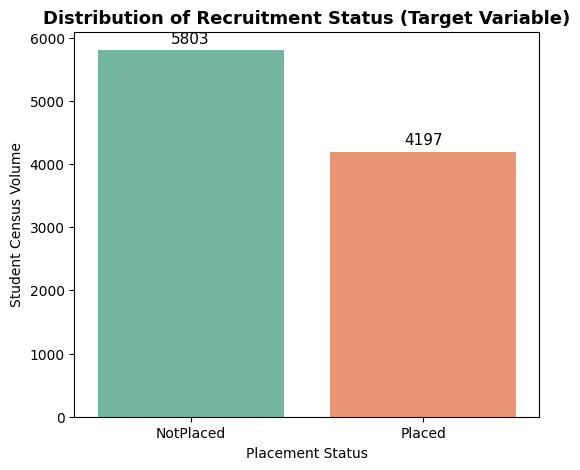

In [48]:

#PLOTTING THE TARGET COMPONENT
plt.figure(figsize=(6, 5))
ax = sns.countplot(x='PlacementStatus', data=df, palette='Set2')
plt.title("Distribution of Recruitment Status (Target Variable)", fontsize=13, fontweight='bold')
plt.xlabel("Placement Status")
plt.ylabel("Student Census Volume")

# Annotate counting volumes on top of columns
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=11, xytext=(0, 5), textcoords='offset points')
plt.show()

 Impact of Scholastic Performance Tracks
In this segment, we evaluate a student's academic history across three primary educational phases to isolate milestones that impact employment selection:
1. **Graduation CGPA (Undergraduate Threshold)**
2. **SSC Marks (10th Grade Percentage)**
3. **HSC Marks (12th Grade Percentage)**

 Key Strategic Insights:
- **The Critical CGPA Boundary:** The stacked histogram curves show a sharp shift around the **8.0 CGPA** mark. Beyond this inflection point, the density of Placed profiles eclipses the unselected crowd, indicating that university grades serve as a primary eligibility gatekeeper for recruiters.
- **Historical Consistency:** The continuous distributions for SSC_Marks and HSC_Marks reveal an upward trend where high school scores over **75%** strongly correspond to final college placement victory, illustrating that academic habits carry significant forward momentum.

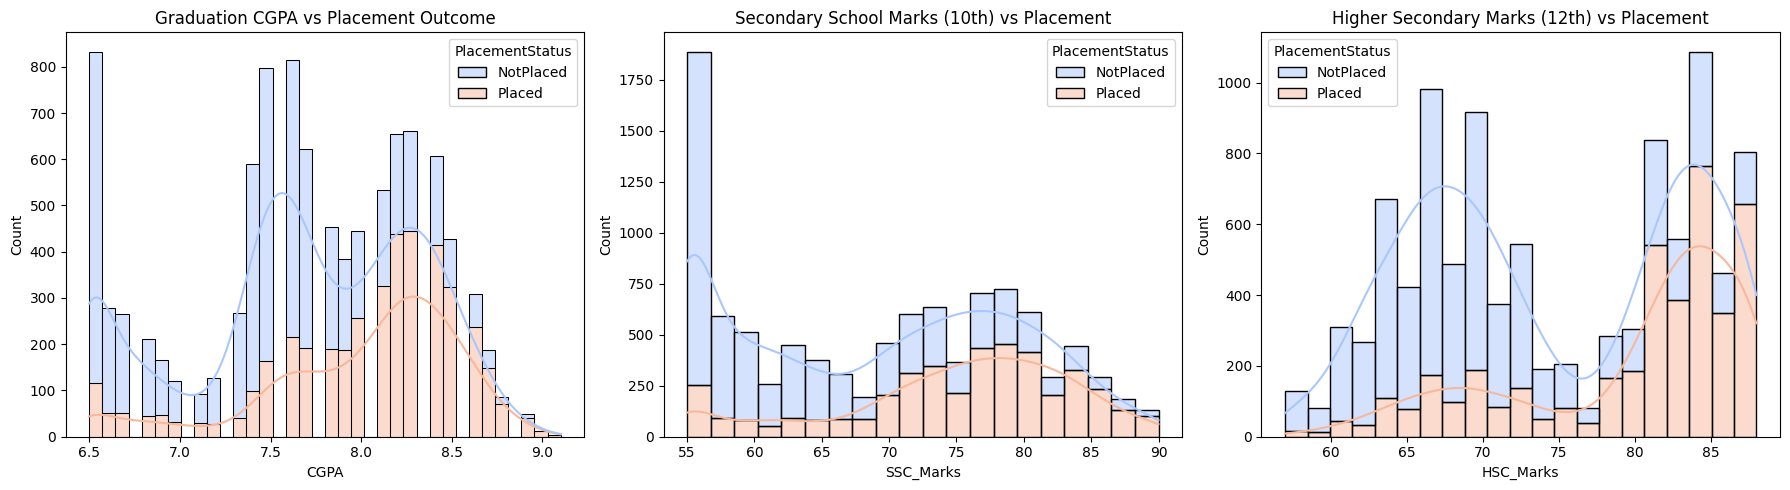

In [47]:

#ACADEMIC METRICS DISTRIBUTION (Histograms)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# CGPA Distribution Matrix
sns.histplot(data=df, x='CGPA', hue='PlacementStatus', kde=True, multiple='stack', ax=axes[0], palette='coolwarm')
axes[0].set_title("Graduation CGPA vs Placement Outcome")

# SSC School Performance Distribution
sns.histplot(data=df, x='SSC_Marks', hue='PlacementStatus', kde=True, multiple='stack', ax=axes[1], palette='coolwarm')
axes[1].set_title("Secondary School Marks (10th) vs Placement")

# HSC Performance Distribution
sns.histplot(data=df, x='HSC_Marks', hue='PlacementStatus', kde=True, multiple='stack', ax=axes[2], palette='coolwarm')
axes[2].set_title("Higher Secondary Marks (12th) vs Placement")

plt.tight_layout()
plt.show()

 Skill Score Variance & Statistical Whisker Distribution
Beyond strict textbook scores, functional attributes play a major role in late-stage interview performance. Here, we implement **Boxplots** to extract the median, spread, and check for outliers across two performance matrices:
- **Aptitude Test Score (Standardized Cognitive & Logic Score)**
- **Soft Skills Rating (Behavioral, Leadership, and Presentation Rating out of 5.0)**

 Key Strategic Insights:
- **Aptitude Test Leverage:** The median marker line for the Placed student bracket sits substantially higher than that of the unselected group. This highlights that a high aptitude score is an essential barrier to clear initial technical elimination rounds.
- **The Soft Skills Advantage:** Candidates securing premium ratings between **4.0 and 5.0** experience excellent recruitment conversion rates, confirming that refined behavioral traits act as definitive conversion drivers during human resource panels.

/tmp/ipykernel_1123/3672806436.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='PlacementStatus', y='AptitudeTestScore', data=df, ax=axes[0], palette='pastel')
/tmp/ipykernel_1123/3672806436.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='PlacementStatus', y='SoftSkillsRating', data=df, ax=axes[1], palette='pastel')


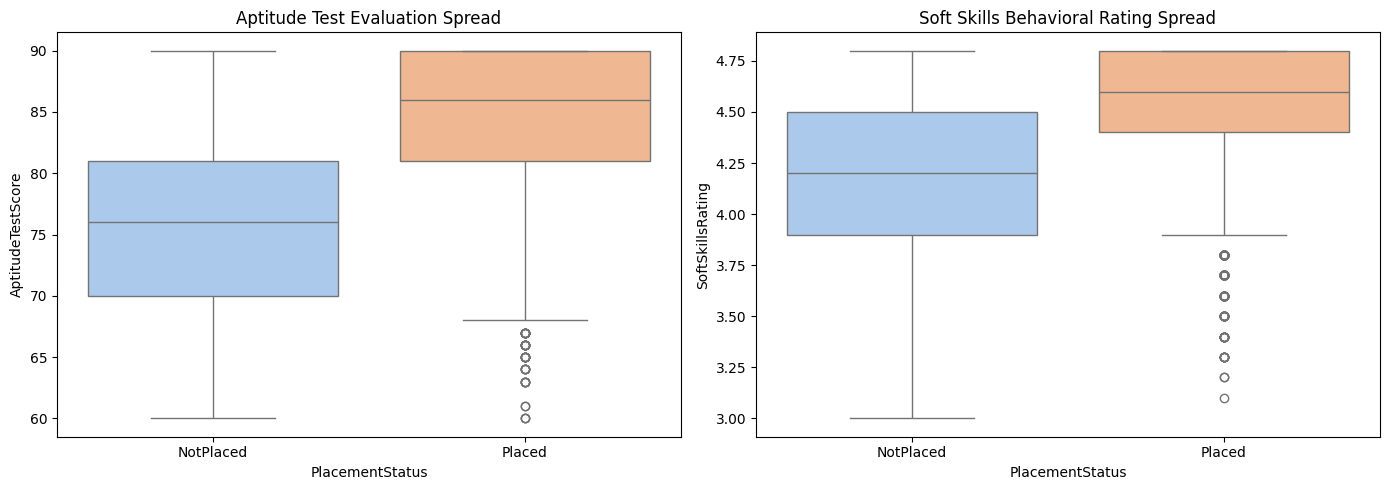

In [46]:

#COMPETENCY MATRICES EVALUATION (Boxplots)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Aptitude Test Scores Boxplot
sns.boxplot(x='PlacementStatus', y='AptitudeTestScore', data=df, ax=axes[0], palette='pastel')
axes[0].set_title("Aptitude Test Evaluation Spread")

# Soft Skills Ratings Boxplot
sns.boxplot(x='PlacementStatus', y='SoftSkillsRating', data=df, ax=axes[1], palette='pastel')
axes[1].set_title("Soft Skills Behavioral Rating Spread")

plt.tight_layout()
plt.show()

 Value of Institutional Training Programs & Active Engagement
This section gauges the direct impact of systematic training infrastructure (**PlacementTraining**) and secondary personal exploration (**ExtracurricularActivities**) using side-by-side behavioral indicators.

 Key Strategic Insights:
- **Training as an Accelerator:** Students who proactively completed the university's custom PlacementTraining module (Yes) secure a drastically higher ratio of employment conversions compared to untrained candidates.
- **Holistic Profile Engineering:** Participation in ExtracurricularActivities points to well-rounded candidate profiles. This indicates to recruiters that a student possesses vital workplace soft skills like teamwork, pressure tolerance, and interpersonal capability.

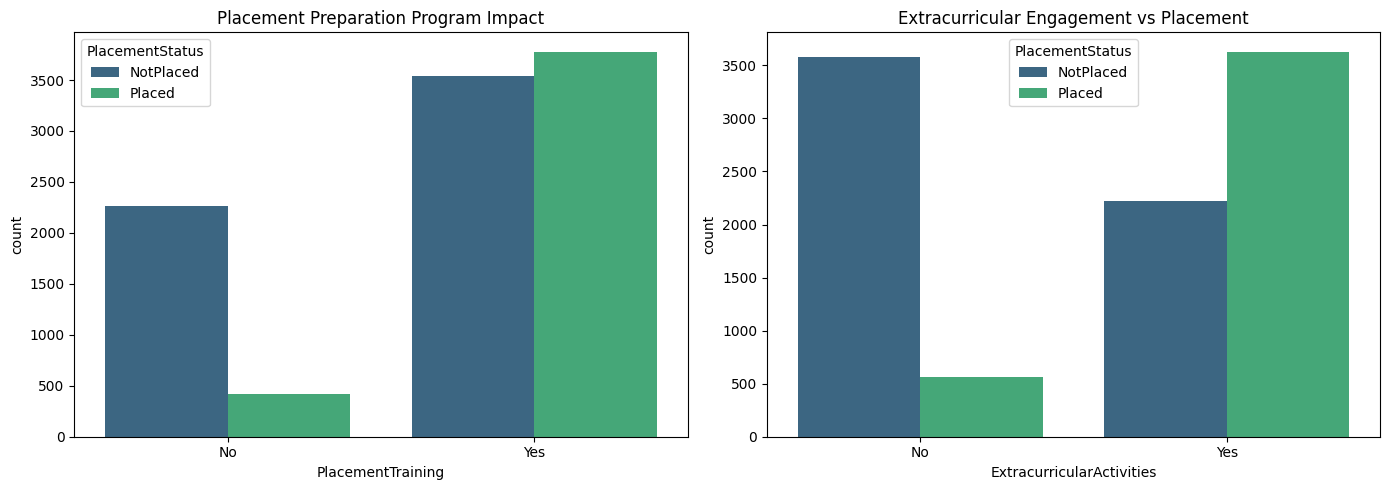

In [45]:

 #PREPARATION METRICS (Training & Extracurriculars)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Impact of Placement Training
sns.countplot(x='PlacementTraining', hue='PlacementStatus', data=df, ax=axes[0], palette='viridis')
axes[0].set_title("Placement Preparation Program Impact")

# Impact of Extracurricular Activities
sns.countplot(x='ExtracurricularActivities', hue='PlacementStatus', data=df, ax=axes[1], palette='viridis')
axes[1].set_title("Extracurricular Engagement vs Placement")

plt.tight_layout()
plt.show()

##Correlation Analysis

 Quantitative Feature Correlation Heatmap
To construct a mathematically optimized machine learning environment, we must evaluate linear relationship scores across variables. For this calculation, the string classes in PlacementStatus have been temporarily mapped to integer parameters (Placed=1, NotPlaced=0).

Correlation Range Guide:
- **+1.00:** Perfect positive linear relationship (direct alignment).
- **0.00:** Absolute linear independence between attributes.
- **-1.00:** Perfect negative linear relationship (inverse proportionality).

 Critical Pre-Modeling Takeaways:
1. **Dominant Feature Vectors:** PlacementStatus displays itshighest structural affinity scores with **CGPA`** and **AptitudeTestScore**. These features will act as prime information drivers when building classification trees or boundary splits.
2. **Multicollinearity Screening:** Independent parameters (e.g., cross-referencing high school marks vs project counts) display stable, non-overlapping correlation thresholds. This guarantees that our data matrix is free of duplicate information dependencies.

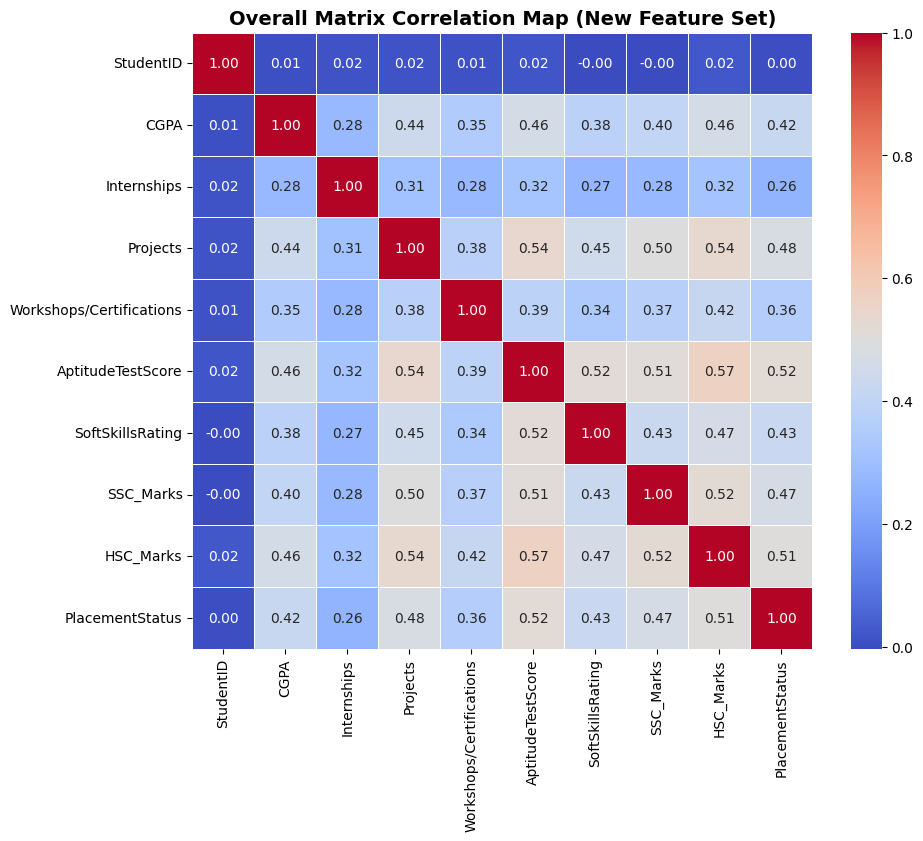

In [44]:

#CORRELATION INTERFACE (Heatmap)
plt.figure(figsize=(10, 8))

# Map target text parameters temporarily to integers for quantitative calculation
corr_df = df.copy()
corr_df['PlacementStatus'] = corr_df['PlacementStatus'].map({'Placed': 1, 'NotPlaced': 0})

# Select only numeric indices
numerical_corr = corr_df.select_dtypes(include=['int64', 'float64']).corr()

# Draw heatmap interface
sns.heatmap(numerical_corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, linewidths=0.5)
plt.title("Overall Matrix Correlation Map (New Feature Set)", fontsize=14, fontweight='bold')
plt.show()

 Comprehensive Summary of Exploratory Data Analysis (EDA)

Following an in-depth data visualization and analytical exploration of all 10,000 student profiles, we have established several key parameters:

1. **Flawless Data Integrity:** Data quality checks confirm zero missing entries across the dataset. The absolute completeness of this data allows us to bypass manual data imputation steps.
2. **The Pillars of Placement Success:** Undergraduate **CGPA**, **Aptitude Test Scores**, and **Soft Skills Ratings** emerge as the most vital predictive attributes dictating recruitment outcomes.
3. **Strategic Preparatory Buffers:** Formal university preparation modules, combined with consistent involvement in internships and projects, strongly push average profiles out of the high-risk rejection zone.

